# 01 — Pixels → One Neuron (PyTorch)

MNIST reaches the model as 784 normalized pixel intensities. A neuron is a weighted evidence accumulator: each active pixel contributes $w_ix_i$ to the pre-activation.


train (5000, 784) test (1000, 784)


label 0 z -0.3811134696006775 ReLU 0.0


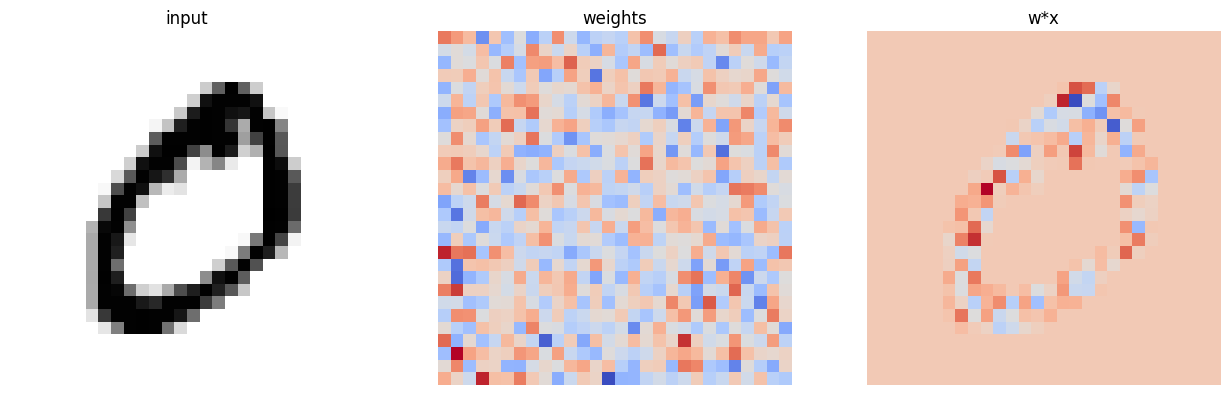

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import torch,matplotlib.pyplot as plt
torch.manual_seed(42);x=torch.tensor(x_train[0]);w=torch.randn(784)*.05;b=torch.tensor(.1);z=torch.dot(x,w)+b;a=torch.relu(z);contrib=(x*w).numpy();print('label',int(y_train[0]),'z',z.item(),'ReLU',a.item());fig,axes=plt.subplots(1,3,figsize=(13,4));axes[0].imshow(x_train_img[0],cmap='gray_r');axes[0].axis('off');axes[1].imshow(w.numpy().reshape(28,28),cmap='coolwarm');axes[1].axis('off');axes[2].imshow(contrib.reshape(28,28),cmap='coolwarm');axes[2].axis('off');axes[0].set_title('input');axes[1].set_title('weights');axes[2].set_title('w*x');plt.tight_layout();plt.show()


## What affects what?
- active pixel × positive weight pushes the neuron upward
- active pixel × negative weight pushes it downward
- bias shifts the response for every sample
- activation controls what is allowed to propagate

**Engineering connection:** this is the primitive form of attribution/debugging—inspect which inputs and parameters created an activation.
